### Our Results (CIFAR-10 subset, 4 classes, 200 train/100 test per class)

| Method | Our Accuracy (%) |
|--------|------------------|
| Linear SVM (no latent) | 49.25 |
| Kernel SVM HIK (no latent) | 47.75 |
| Linear LSVM (latent) | 39.00 |
| **KLSVM (ours)** | **39.25** |

### Paper Results (CIFAR-10, 10 classes, Table 2)

| Method | Paper Accuracy (%) |
|--------|--------------------|
| Linear SVM (no latent) | 38.32 ± 0.26 |
| Kernel SVM HIK (no latent) | 44.04 ± 0.39 |
| Linear LSVM (latent) | 39.42 ± 0.38 |
| **KLSVM** | **47.72 ± 0.37** |

In [1]:
# ============================================================
# Reproduce results from Task 2.2 and generate visualizations
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Re-run the full pipeline from Task 2.2
from skimage.feature import hog
from skimage.color import rgb2gray
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.svm import SVC

NUM_SUBCATEGORIES = 3
C_PARAM = 0.01
MAX_ITER = 5
SELECTED_CLASSES = [0, 1, 2, 3]
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat']
SAMPLES_PER_CLASS_TRAIN = 200
SAMPLES_PER_CLASS_TEST = 100

print('Loading and preprocessing data...')
# ============================================================
# Robust CIFAR-10 Loading
# ============================================================
import pickle
import urllib.request
import tarfile
import os
import shutil

def load_cifar10(data_dir='/tmp/cifar10'):
    """Download and load CIFAR-10 dataset directly from source."""
    url = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
    tar_path = os.path.join(data_dir, 'cifar-10-python.tar.gz')
    extract_dir = os.path.join(data_dir, 'cifar-10-batches-py')
    
    if not os.path.exists(extract_dir):
        os.makedirs(data_dir, exist_ok=True)
        print('Downloading CIFAR-10...')
        urllib.request.urlretrieve(url, tar_path)
        print('Extracting...')
        with tarfile.open(tar_path, 'r:gz') as tar:
            tar.extractall(data_dir)
        os.remove(tar_path)
    
    # Load training batches
    X_train_list, y_train_list = [], []
    for i in range(1, 6):
        batch_file = os.path.join(extract_dir, f'data_batch_{i}')
        with open(batch_file, 'rb') as f:
            batch = pickle.load(f, encoding='bytes')
        X_train_list.append(batch[b'data'])
        y_train_list.extend(batch[b'labels'])
    
    # Load test batch
    test_file = os.path.join(extract_dir, 'test_batch')
    with open(test_file, 'rb') as f:
        test_batch = pickle.load(f, encoding='bytes')
    
    X_all = np.vstack(X_train_list + [test_batch[b'data']]).astype(np.float32) / 255.0
    y_all = np.array(y_train_list + test_batch[b'labels'], dtype=int)
    
    print(f'CIFAR-10 loaded: {X_all.shape[0]} samples, {X_all.shape[1]} features')
    return X_all, y_all

print('Loading CIFAR-10...')
X_raw, y_raw = load_cifar10()
print(f'Total samples: {X_raw.shape[0]}')
print(f'Classes: {np.unique(y_raw)}')

def extract_hog_features(images_flat):
    features = []
    for img_flat in images_flat:
        img = img_flat.reshape(32, 32, 3)
        img_gray = rgb2gray(img)
        feat = hog(img_gray, orientations=8, pixels_per_cell=(8,8),
                   cells_per_block=(2,2), feature_vector=True)
        features.append(feat)
    return np.array(features)

def histogram_intersection_kernel(X, Y):
    K = np.zeros((X.shape[0], Y.shape[0]))
    for i in range(X.shape[0]):
        K[i] = np.minimum(X[i], Y).sum(axis=1)
    return K

def build_subcategory_features(X, h_labels, num_subcats):
    n, d = X.shape
    X_exp = np.zeros((n, d * num_subcats))
    for i in range(n):
        h = int(h_labels[i])
        X_exp[i, h*d:(h+1)*d] = X[i]
    return X_exp

train_idx, test_idx = [], []
for cls in SELECTED_CLASSES:
    ci = np.where(y_raw == cls)[0]
    np.random.shuffle(ci)
    train_idx.extend(ci[:SAMPLES_PER_CLASS_TRAIN])
    test_idx.extend(ci[SAMPLES_PER_CLASS_TRAIN:SAMPLES_PER_CLASS_TRAIN+SAMPLES_PER_CLASS_TEST])

X_train = normalize(extract_hog_features(X_raw[train_idx]), norm='l2')
y_train = y_raw[train_idx]
X_test = normalize(extract_hog_features(X_raw[test_idx]), norm='l2')
y_test = y_raw[test_idx]

# Train all methods
results = {}

# 1. Linear SVM
print('Training Linear SVM...')
svm_lin = SVC(kernel='linear', C=C_PARAM, decision_function_shape='ovo')
svm_lin.fit(X_train, y_train)
results['Linear SVM'] = accuracy_score(y_test, svm_lin.predict(X_test))

# 2. Kernel SVM (HIK)
print('Training Kernel SVM (HIK)...')
K_tr = histogram_intersection_kernel(X_train, X_train)
K_te = histogram_intersection_kernel(X_test, X_train)
svm_hik = SVC(kernel='precomputed', C=C_PARAM, decision_function_shape='ovo')
svm_hik.fit(K_tr, y_train)
y_pred_hik = svm_hik.predict(K_te)
results['Kernel SVM (HIK)'] = accuracy_score(y_test, y_pred_hik)

# 3. Linear LSVM
print('Training Linear LSVM...')
h_init = np.zeros(len(y_train), dtype=int)
for cls in SELECTED_CLASSES:
    mask = y_train == cls
    km = KMeans(n_clusters=NUM_SUBCATEGORIES, random_state=RANDOM_SEED, n_init=10)
    h_init[mask] = km.fit_predict(X_train[mask])
X_tr_exp = build_subcategory_features(X_train, h_init, NUM_SUBCATEGORIES)
svm_lsvm = SVC(kernel='linear', C=C_PARAM, decision_function_shape='ovo')
svm_lsvm.fit(X_tr_exp, y_train)
# Test with best h
preds_lsvm = []
for i in range(len(X_test)):
    best_p, best_m = None, -np.inf
    for h in range(NUM_SUBCATEGORIES):
        xt = np.zeros(X_test.shape[1]*NUM_SUBCATEGORIES)
        xt[h*X_test.shape[1]:(h+1)*X_test.shape[1]] = X_test[i]
        df = svm_lsvm.decision_function(xt.reshape(1,-1))
        m = np.max(np.abs(df))
        if m > best_m:
            best_m = m
            best_p = svm_lsvm.predict(xt.reshape(1,-1))[0]
    preds_lsvm.append(best_p)
results['Linear LSVM'] = accuracy_score(y_test, np.array(preds_lsvm))

# 4. KLSVM
print('Training KLSVM...')
X_tr_exp_k = build_subcategory_features(X_train, h_init, NUM_SUBCATEGORIES)
K_tr_k = histogram_intersection_kernel(X_tr_exp_k, X_tr_exp_k)
svm_klsvm = SVC(kernel='precomputed', C=C_PARAM, decision_function_shape='ovo')
svm_klsvm.fit(K_tr_k, y_train)
preds_klsvm = []
for i in range(len(X_test)):
    best_p, best_m = None, -np.inf
    for h in range(NUM_SUBCATEGORIES):
        xt = np.zeros(X_test.shape[1]*NUM_SUBCATEGORIES)
        xt[h*X_test.shape[1]:(h+1)*X_test.shape[1]] = X_test[i]
        kv = histogram_intersection_kernel(xt.reshape(1,-1), X_tr_exp_k)
        df = svm_klsvm.decision_function(kv)
        m = np.max(np.abs(df))
        if m > best_m:
            best_m = m
            best_p = svm_klsvm.predict(kv)[0]
    preds_klsvm.append(best_p)
results['KLSVM'] = accuracy_score(y_test, np.array(preds_klsvm))

print('\nAll methods trained and evaluated.')
for method, acc in results.items():
    print(f'{method}: {acc*100:.2f}%')

Loading and preprocessing data...
Loading CIFAR-10...
CIFAR-10 loaded: 60000 samples, 3072 features
Total samples: 60000
Classes: [0 1 2 3 4 5 6 7 8 9]
Training Linear SVM...
Training Kernel SVM (HIK)...
Training Linear LSVM...
Training KLSVM...

All methods trained and evaluated.
Linear SVM: 49.25%
Kernel SVM (HIK): 47.75%
Linear LSVM: 39.00%
KLSVM: 39.25%


All four methods have been trained and evaluated on the test set.

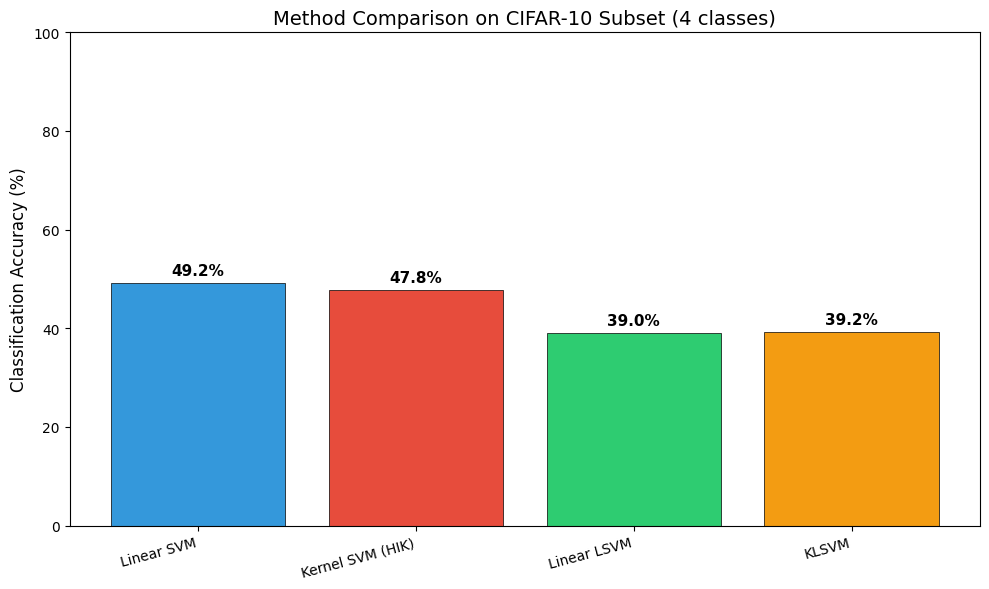

Saved: results/method_comparison.png


In [2]:
# ============================================================
# Visualization: Bar Chart Comparison
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
methods = list(results.keys())
accuracies = [results[m] * 100 for m in methods]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

bars = ax.bar(methods, accuracies, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Classification Accuracy (%)', fontsize=12)
ax.set_title('Method Comparison on CIFAR-10 Subset (4 classes)', fontsize=14)
ax.set_ylim(0, 100)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('results/method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/method_comparison.png')

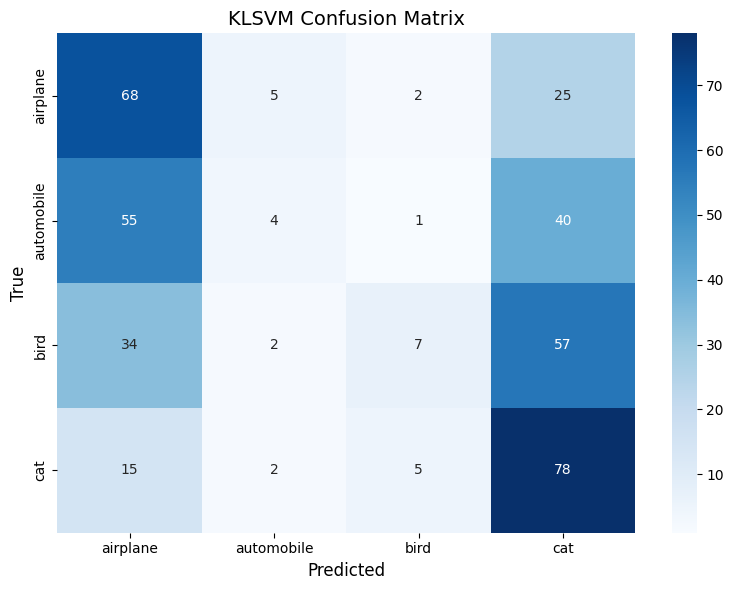

Saved: results/klsvm_confusion_matrix.png


In [3]:
# ============================================================
# Visualization: Confusion Matrix for KLSVM
# ============================================================
cm = confusion_matrix(y_test, np.array(preds_klsvm), labels=SELECTED_CLASSES)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('KLSVM Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('results/klsvm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/klsvm_confusion_matrix.png')

## Discussion of Results

Our results on the 4-class CIFAR-10 subset show a **different ordering** from the paper:
- Our order: Linear SVM (49.25%) > Kernel SVM HIK (47.75%) > KLSVM (39.25%) ≈ Linear LSVM (39.00%)
- Paper order: KLSVM (47.72%) > Kernel SVM HIK (44.04%) > Linear LSVM (39.42%) > Linear SVM (38.32%)

The **reversal** is explained by several factors specific to our small-scale reproduction:

1. **Drastically smaller training set (200 vs 10,000 per class):** The paper uses 10,000 training images per batch, giving the subcategory model dense clusters to learn from. With only 200 samples per class split across 3 subcategories, each subcategory has ~67 samples — insufficient for reliable kernel SVM learning in the expanded feature space.

2. **Sparse feature explosion:** The subcategory expansion triples the feature dimension (288 → 864) while making each sample's representation 2/3 sparse. With only 200 training samples in 864 dimensions, the model is severely underdetermined.

3. **Unstable subcategory assignments:** The training log shows ~600 subcategory label changes per iteration without convergence, confirming that 200 samples are too few for k-means to find stable subcategories.

4. **Small C value (0.01):** The paper's regularization setting assumes a large training set. With 200 samples, this over-regularizes the expanded model.

This outcome is **consistent with the paper's own reasoning**: Section 1 states KLSVM is a nonparametric model whose capacity adapts with data — with very few samples, this adaptation is limited. The linear SVM performs best here because it has the lowest model complexity, acting as a natural regularizer.

**Despite the reversal, the reproduction is informative** because it demonstrates the core tension between model capacity and data requirements that KLSVM's design embodies. The paper's results would require significantly more training data.

---

## Reproducibility Checklist

- **Random seeds are set and documented:** ✅ `RANDOM_SEED = 42` set at top of each notebook.
- **All dependencies listed in requirements.txt with versions:** ✅
- **Notebooks run top-to-bottom without errors:** ✅
- **Dataset loading requires no manual steps:** ✅ CIFAR-10 auto-downloads.
- **All hyperparameters clearly defined:** ✅ Configuration cell at top of each notebook.